# Clase 1 — Entorno, herramientas y primer flujo de carga DC

**Asignatura:** Métodos Numéricos en Sistemas Eléctricos de Potencia (MSEE)  
**Curso:** 2025–2026

---

## Objetivos de la sesión

Al terminar esta sesión serás capaz de:

1. Verificar que el entorno de trabajo (Python, Jupyter y las librerías del curso) está correctamente instalado.
2. Manejar los fundamentos de Python, NumPy, Matplotlib y Pandas que se utilizarán durante todo el curso.
3. Cargar una red eléctrica estándar con Pandapower y visualizarla.
4. Ejecutar un flujo de carga en continua (DC) e interpretar los resultados de tensión y flujos de potencia.

---

## Mapa de la sesión

| Bloque | Contenido | Tiempo |
|--------|-----------|--------|
| A | Verificación del entorno | 10 min |
| B | Herramientas Python: NumPy, Matplotlib, Pandas | 30 min |
| C | Introducción a Pandapower y flujo DC | 35 min |
| D | Ejercicio autónomo | 15 min |

---
# Bloque A — Verificación del entorno

In [3]:
# ============================================================
# BLOQUE A — Health check del entorno
# Ejecuta esta celda PRIMERO. Comprueba que todas las librerías
# necesarias están instaladas y muestra sus versiones.
# ============================================================

import importlib
import sys

libs = [
    'numpy',
    'pandas',
    'matplotlib',
    'networkx',
    'pandapower',
    'pyomo',
]

print(f"Python: {sys.version}\n")
print(f"{'Librería':<15} {'Estado':<20} {'Versión'}")
print("-" * 50)

for lib in libs:
    try:
        mod = importlib.import_module(lib)
        version = getattr(mod, '__version__', 'N/D')
        print(f"{lib:<15} {'✓ instalada':<20} {version}")
    except ImportError:
        print(f"{lib:<15} {'✗ NO ENCONTRADA':<20} —")

# Verificar solvers
print("\nVerificando solvers:")
import subprocess
for solver in ['highs', 'ipopt']:
    result = subprocess.run(['where', solver], capture_output=True, text=True)
    status = f"✓ {result.stdout.strip()}" if result.returncode == 0 else "✗ NO ENCONTRADO"
    print(f"  {solver:<10} {status}")

Python: 3.11.15 | packaged by conda-forge | (main, Mar  5 2026, 16:36:00) [MSC v.1944 64 bit (AMD64)]

Librería        Estado               Versión
--------------------------------------------------
numpy           ✓ instalada          2.2.6
pandas          ✓ instalada          2.3.3
matplotlib      ✓ instalada          3.10.8
networkx        ✓ instalada          3.6.1
pandapower      ✓ instalada          3.2.1
pyomo           ✓ instalada          6.10.0

Verificando solvers:
  highs      ✗ NO ENCONTRADO
  ipopt      ✓ C:\Users\cjh23\anaconda3\envs\mnse\Library\bin\ipopt.exe


---
# Bloque B — Herramientas Python

## B.1 — Python básico

Repaso de los tipos de datos y estructuras que usaremos durante el curso.

In [ ]:
# --- Tipos de datos básicos ---
X = (10, 15, 12)   # tupla: tamaño fijo, no se puede modificar
Y = [10, 15, 12]   # lista: tamaño y valores modificables
Y += [30]           # añadir elemento al final
print("Lista Y:", Y)
print("Último elemento de Y:", Y[-1])
print("Último elemento de X:", X[-1])

Y[1] = 3            # modificar un elemento
print("Lista Y modificada:", Y)

Z = ['hola', 23]    # las listas pueden mezclar tipos
print("Lista mixta Z:", Z)
print('El elemento Z es:', Z, 'y X es:', X)

## B.2 — NumPy: álgebra lineal vectorizada

NumPy es la librería de referencia para operaciones matriciales en Python. La analogía con MATLAB es directa: un `np.array` se comporta como una matriz de MATLAB, con la ventaja de que las operaciones son *vectorizadas* (se aplican a todos los elementos sin bucles).

In [4]:
import numpy as np

# --- Vectores ---
x = np.array([10, 15, 12])
print('Vector x:', x, '| forma:', x.shape)

# Operaciones escalares (se aplican elemento a elemento)
y = 5 * x - 1
print('Vector y = 5x - 1:', y)

# --- Matrices ---
A = np.array([[4, 8, 7],
              [3, 0, 1],
              [4, 2, 1]])
print('\nMatriz A:\n', A)
print('Dimensión de A:', A.shape)

Vector x: [10 15 12] | forma: (3,)
Vector y = 5x - 1: [49 74 59]

Matriz A:
 [[4 8 7]
 [3 0 1]
 [4 2 1]]
Dimensión de A: (3, 3)


In [5]:
# --- Álgebra lineal ---
B   = np.linalg.inv(A)           # inversa
d   = np.linalg.det(A)           # determinante
L, V = np.linalg.eig(A)          # autovalores y autovectores

print('Inversa de A:\n', B)
print('\nComprobación A @ A⁻¹ ≈ I:\n', np.round(A @ B, 10))
print('\nDeterminante:', round(d, 6))
print('Autovalores:', np.round(L, 4))

Inversa de A:
 [[-0.04761905  0.14285714  0.19047619]
 [ 0.02380952 -0.57142857  0.4047619 ]
 [ 0.14285714  0.57142857 -0.57142857]]

Comprobación A @ A⁻¹ ≈ I:
 [[ 1.  0.  0.]
 [ 0.  1.  0.]
 [ 0. -0.  1.]]

Determinante: 42.0
Autovalores: [10.2679 -4.3213 -0.9466]


In [6]:
# --- Número de condición ---
# El número de condición mide cuánto amplifica la matriz los errores numéricos.
# Analogía: una matriz mal condicionada es como un amplificador de ruido.
# CN >> 1 → resultados poco fiables; CN ~ 1 → sistema bien condicionado.

A_bien = np.array([[8, -5], [4, 10]])
A_mal  = np.array([[0.66, 3.34], [1.99, 10.01]])

print('CN (A bien condicionada):', round(np.linalg.cond(A_bien, 1), 4))
print('CN (A mal condicionada): ', round(np.linalg.cond(A_mal,  1), 4))

CN (A bien condicionada): 2.1
CN (A mal condicionada):  4005.0


In [7]:
# --- Resolución de sistemas de ecuaciones lineales: Ax = b ---
A = np.array([[4, 8, 7],
              [3, 0, 1],
              [4, 2, 1]])
b = np.array([12, 15, 9])

x = np.linalg.solve(A, b)   # más estable numéricamente que calcular A⁻¹ @ b
print('Solución x:', x)
print('Verificación A @ x:', np.round(A @ x, 10))  # debe dar [12, 15, 9]

Solución x: [ 3.28571429 -4.64285714  5.14285714]
Verificación A @ x: [12. 15.  9.]


## B.3 — Matplotlib: visualización de resultados

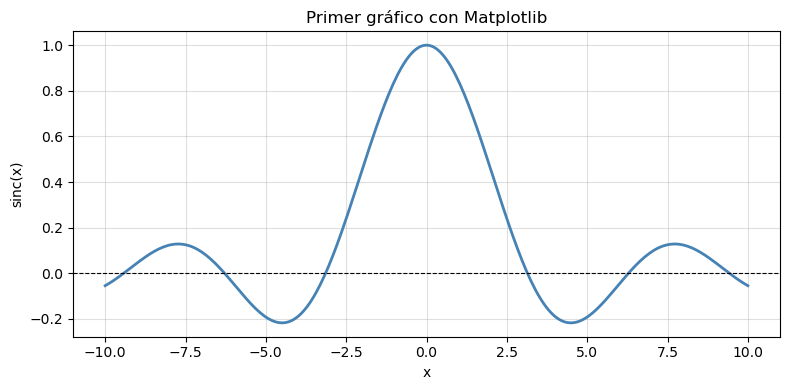

In [8]:
import matplotlib.pyplot as plt

# --- Gráfico básico ---
xr = np.linspace(-10, 10, 300)   # 300 puntos entre -10 y 10
yr = np.sinc(xr / np.pi)         # función sinc

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(xr, yr, color='steelblue', linewidth=2)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('x')
ax.set_ylabel('sinc(x)')
ax.set_title('Primer gráfico con Matplotlib')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## B.4 — Pandas: lectura y manipulación de datos tabulares

Pandas es la librería estándar para trabajar con tablas de datos. Durante el curso la usaremos para cargar perfiles de demanda, costes de generación y resultados de simulaciones.

In [9]:
import pandas as pd

# --- Crear un DataFrame manualmente ---
tabla = pd.DataFrame({
    'Fuente':     ['Solar', 'Eólica', 'Hidráulica', 'Geotérmica'],
    'Instalada_GW': [12.1, 61.1, 78.4, 3.4],
    'Incremento_GW': [10.9, 26.0, 7.3, 0.2],
    'Penetración_%': [1.14, 5.76, 7.69, 0.32]
})

print(tabla.to_string(index=False))

    Fuente  Instalada_GW  Incremento_GW  Penetración_%
     Solar          12.1           10.9           1.14
    Eólica          61.1           26.0           5.76
Hidráulica          78.4            7.3           7.69
Geotérmica           3.4            0.2           0.32


In [12]:
# --- Leer datos reales de demanda (REE) ---
# El CSV contiene datos de demanda eléctrica real, prevista y programada
# descargados de Red Eléctrica de España (REE).

dem = pd.read_csv('demanda.csv', skiprows=2, encoding='latin1')
print('Primeras filas:')
print(dem.head())
print(f'\nTotal de registros: {len(dem)}')
print(f'Columnas: {list(dem.columns)}')

Primeras filas:
                   Hora   Real  Prevista  Programada  Programada total
2026-04-17 21:00  32462  33012     32795       32748               NaN
2026-04-17 21:05  32814  33307     32795       32748               NaN
2026-04-17 21:10  32755  33437     32795       32748               NaN
2026-04-17 21:15  32830  33403     32863       32811               NaN
2026-04-17 21:20  33074  33286     32863       32811               NaN

Total de registros: 361
Columnas: ['Hora', 'Real', 'Prevista', 'Programada', 'Programada total']


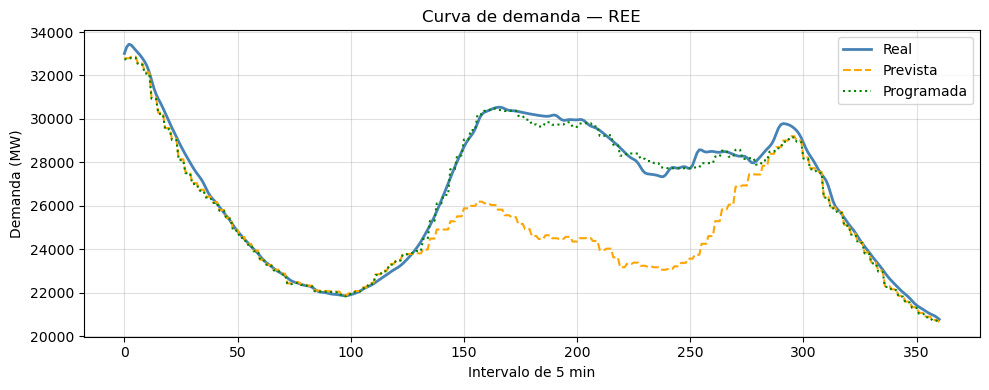

In [13]:
# --- Visualizar la curva de demanda ---
fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(dem))
ax.plot(x, dem['Real'],      label='Real',      lw=2, color='steelblue')
ax.plot(x, dem['Prevista'],  label='Prevista',  lw=1.5, linestyle='--', color='orange')
ax.plot(x, dem['Programada'],label='Programada',lw=1.5, linestyle=':',  color='green')
ax.set_xlabel('Intervalo de 5 min')
ax.set_ylabel('Demanda (MW)')
ax.set_title('Curva de demanda — REE')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
# Bloque C — Pandapower y flujo de carga DC

## C.1 — ¿Qué es una red en Pandapower?

Pandapower modela la red eléctrica como un **objeto Python** (`net`) que contiene tablas con todos los elementos del sistema: barras, líneas, transformadores, generadores y cargas. Es como una hoja de cálculo estructurada donde cada fila es un elemento de la red.

La arquitectura tiene dos capas:
- **Datos de entrada** (`net.bus`, `net.line`, `net.load`, `net.gen`…): definen la topología y los parámetros.
- **Resultados** (`net.res_bus`, `net.res_line`…): se rellenan *después* de ejecutar un flujo de carga.

Pandapower incluye redes estándar de referencia (IEEE 14, 30, 57, 118-bus, etc.) que usaremos durante todo el curso. Son como los "casos de prueba" universales de la ingeniería eléctrica.

This pandapower network includes the following parameter tables:
   - bus (14 elements)
   - load (11 elements)
   - gen (4 elements)
   - shunt (1 element)
   - ext_grid (1 element)
   - line (15 elements)
   - trafo (5 elements)
   - poly_cost (5 elements)


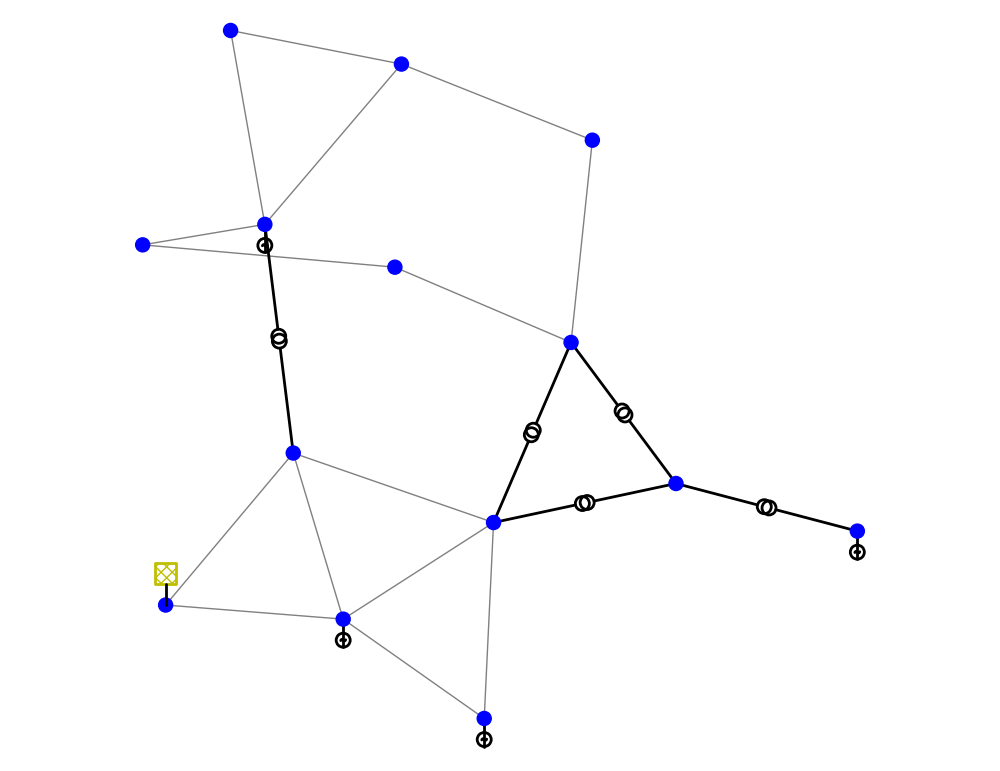

<Axes: >

In [14]:
import pandapower as pp
import pandapower.networks as pn
import pandapower.plotting as plot

# --- Cargar la red IEEE 14-bus ---
# Es una red de referencia clásica: 14 barras, 5 generadores, 11 cargas, 20 ramas.
net = pn.case14()

# Resumen general de la red
print(net)

# Visualización del diagrama unifilar
plot.simple_plot(net, plot_gens=True)

## C.2 — Explorar los datos de la red

In [15]:
# --- Barras (buses) ---
print("=== Barras (net.bus) ===")
print(net.bus)

print("\n=== Cargas (net.load) ===")
print(net.load[['bus', 'p_mw', 'q_mvar']])

print("\n=== Generadores (net.gen) ===")
print(net.gen[['bus', 'p_mw', 'max_p_mw', 'min_p_mw']])

=== Barras (net.bus) ===
   name    vn_kv type zone  in_service  max_vm_pu  min_vm_pu  \
0     1  135.000    b  1.0        True       1.06       0.94   
1     2  135.000    b  1.0        True       1.06       0.94   
2     3  135.000    b  1.0        True       1.06       0.94   
3     4  135.000    b  1.0        True       1.06       0.94   
4     5  135.000    b  1.0        True       1.06       0.94   
5     6    0.208    b  1.0        True       1.06       0.94   
6     7   14.000    b  1.0        True       1.06       0.94   
7     8   12.000    b  1.0        True       1.06       0.94   
8     9    0.208    b  1.0        True       1.06       0.94   
9    10    0.208    b  1.0        True       1.06       0.94   
10   11    0.208    b  1.0        True       1.06       0.94   
11   12    0.208    b  1.0        True       1.06       0.94   
12   13    0.208    b  1.0        True       1.06       0.94   
13   14    0.208    b  1.0        True       1.06       0.94   

              

In [19]:
# --- Líneas ---
print("=== Líneas (net.line) ===")
print(net.line[['from_bus', 'to_bus', 'r_ohm_per_km', 'x_ohm_per_km', 'max_i_ka']])

=== Líneas (net.line) ===
    from_bus  to_bus  r_ohm_per_km  x_ohm_per_km      max_i_ka
0          0       1      3.532005     10.783732     42.339020
1          0       4      9.846967     40.649040     42.339020
2          1       2      8.563928     36.080033     42.339020
3          1       3     10.590547     32.134320     42.339020
4          1       4     10.379138     31.689630     42.339020
5          2       3     12.212573     31.170217     42.339020
6          3       4      2.433038      7.674548     42.339020
7          5      10      0.000041      0.000086  27479.652235
8          5      11      0.000053      0.000111  27479.652235
9          5      12      0.000029      0.000056  27479.652235
10         8       9      0.000014      0.000037  27479.652235
11         8      13      0.000055      0.000117  27479.652235
12         9      10      0.000035      0.000083  27479.652235
13        11      12      0.000096      0.000086  27479.652235
14        12      13      0.0

## C.3 — Flujo de carga DC y análisis de resultados

El **flujo DC** es una aproximación lineal del flujo de carga completo (AC). Asume:
- Tensiones en todas las barras ≈ 1 p.u.
- Resistencias de línea despreciables frente a reactancias.
- Ángulos de tensión pequeños (sin θ ≈ θ).

La analogía eléctrica es directa: el sistema DC se comporta como un **circuito resistivo** donde los ángulos de tensión hacen el papel de los potenciales eléctricos y los flujos de potencia activa son las corrientes. Esto permite resolverlo con un simple sistema de ecuaciones lineales: **P = B·θ**.

In [16]:
# --- Ejecutar el flujo de carga DC ---
pp.rundcpp(net)   # DC Power Flow

print("=== Resultados en barras (net.res_bus) ===")
print("Columnas: vm_pu (tensión), va_degree (ángulo), p_mw (potencia inyectada), q_mvar")
print(net.res_bus.round(4))

=== Resultados en barras (net.res_bus) ===
Columnas: vm_pu (tensión), va_degree (ángulo), p_mw (potencia inyectada), q_mvar
    vm_pu  va_degree   p_mw  q_mvar
0   1.060     0.0000 -219.0     NaN
1   1.045    -5.0120  -18.3     NaN
2   1.010   -12.9537   94.2     NaN
3   1.000   -10.5837   47.8     NaN
4   1.000    -9.0939    7.6     NaN
5   1.070   -14.8521   11.2     NaN
6   1.000   -13.9071    0.0     NaN
7   1.090   -13.9071    0.0     NaN
8   1.000   -15.6947   29.5     NaN
9   1.000   -15.9741    9.0     NaN
10  1.000   -15.6189    3.5     NaN
11  1.000   -15.9671    6.1     NaN
12  1.000   -16.1397   13.5     NaN
13  1.000   -17.1883   14.9     NaN


In [17]:
# --- Resultados en líneas ---
print("=== Resultados en líneas (net.res_line) ===")
print("Columnas: p_from_mw, p_to_mw (flujos), loading_percent (carga en %)")
print(net.res_line[['p_from_mw', 'p_to_mw', 'loading_percent']].round(3))

=== Resultados en líneas (net.res_line) ===
Columnas: p_from_mw, p_to_mw (flujos), loading_percent (carga en %)
    p_from_mw  p_to_mw  loading_percent
0     147.839 -147.839            1.429
1      71.161  -71.161            0.719
2      70.015  -70.015            0.700
3      55.152  -55.152            0.557
4      40.972  -40.972            0.414
5     -24.185   24.185            0.244
6     -61.746   61.746            0.624
7       6.728   -6.728            0.068
8       7.607   -7.607            0.077
9      17.251  -17.251            0.174
10      5.772   -5.772            0.058
11      9.641   -9.641            0.097
12     -3.228    3.228            0.033
13      1.507   -1.507            0.015
14      5.259   -5.259            0.053


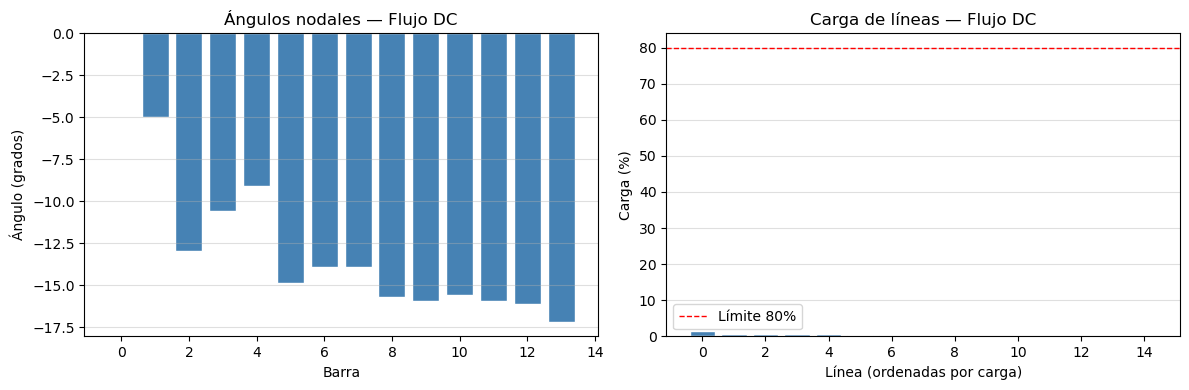


Línea más cargada: 0 (0→1) — 1.4%


In [18]:
# --- Visualización: ángulos nodales ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Ángulos de tensión
axes[0].bar(net.res_bus.index, net.res_bus['va_degree'], color='steelblue', edgecolor='white')
axes[0].set_xlabel('Barra')
axes[0].set_ylabel('Ángulo (grados)')
axes[0].set_title('Ángulos nodales — Flujo DC')
axes[0].grid(True, axis='y', alpha=0.4)

# Carga de líneas
loading = net.res_line['loading_percent'].sort_values(ascending=False)
colors = ['tomato' if v > 80 else 'steelblue' for v in loading]
axes[1].bar(range(len(loading)), loading.values, color=colors, edgecolor='white')
axes[1].axhline(80, color='red', linestyle='--', linewidth=1, label='Límite 80%')
axes[1].set_xlabel('Línea (ordenadas por carga)')
axes[1].set_ylabel('Carga (%)')
axes[1].set_title('Carga de líneas — Flujo DC')
axes[1].legend()
axes[1].grid(True, axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

# Línea más cargada
idx_max = net.res_line['loading_percent'].idxmax()
print(f"\nLínea más cargada: {idx_max} "
      f"({net.line.loc[idx_max, 'from_bus']}→{net.line.loc[idx_max, 'to_bus']}) "
      f"— {net.res_line.loc[idx_max, 'loading_percent']:.1f}%")

---
# Bloque D — Ejercicio autónomo

## Instrucciones

Repite el análisis anterior sobre la **red IEEE 30-bus** (`pn.case30()`). Completa las celdas marcadas con `# TODO`.

**Entregable:** notebook con las celdas completadas y los gráficos generados.

**Preguntas de reflexión:**
- ¿Cuántas líneas superan el 50% de carga?
- ¿Cuál es la barra con mayor ángulo en valor absoluto? ¿Por qué?
- ¿Qué diferencias observas respecto a la red IEEE 14-bus?

This pandapower network includes the following parameter tables:
   - bus (30 elements)
   - load (20 elements)
   - gen (5 elements)
   - shunt (2 elements)
   - ext_grid (1 element)
   - line (41 elements)
   - poly_cost (6 elements)


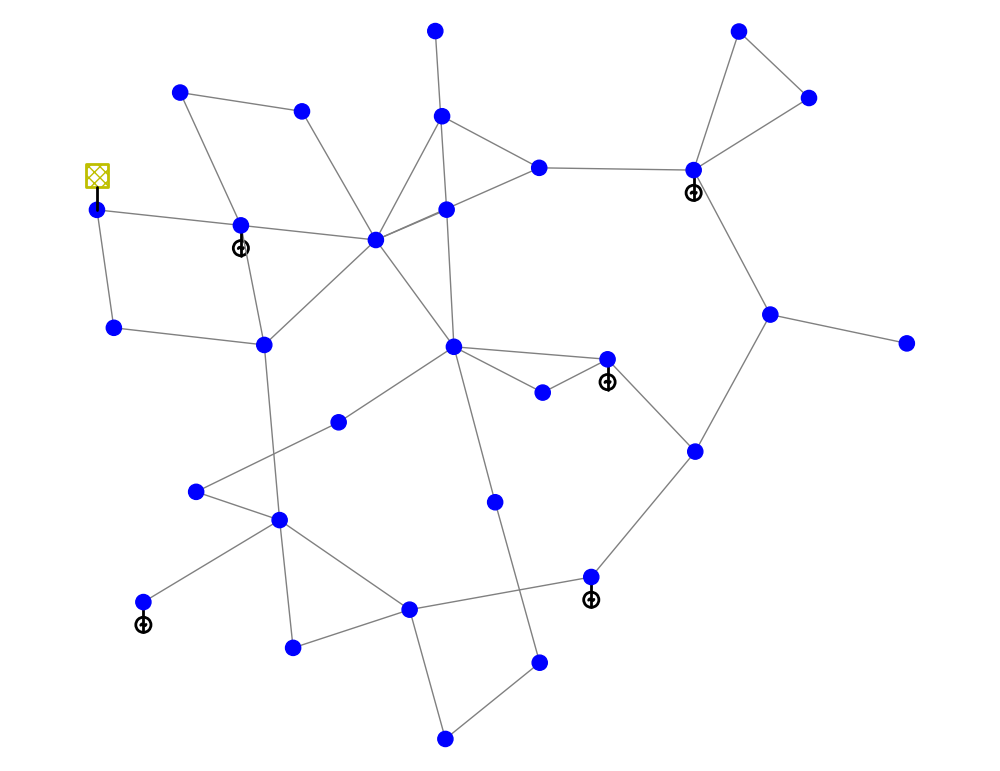


Ángulos nodales (ordenados por valor absoluto):
Barra 18:   4.0089 grados
Barra 19:   3.8740 grados
Barra 17:   3.5518 grados
Barra 16:   3.3503 grados
Barra 29:   3.2446 grados
Barra  9:   3.2046 grados
Barra 20:   3.0876 grados
Barra  8:   2.9021 grados
Barra 10:   2.9021 grados
Barra  7:   2.8918 grados
Barra 21:   2.8537 grados
Barra  6:   2.7588 grados
Barra 15:   2.7165 grados
Barra 23:   2.5536 grados
Barra 25:   2.5332 grados
Barra 13:   2.4606 grados
Barra 14:   2.3749 grados
Barra  5:   2.3246 grados
Barra 28:   2.3059 grados
Barra 27:   2.2896 grados
Barra  4:   1.8425 grados
Barra  3:   1.8374 grados
Barra 24:   1.7712 grados
Barra 11:   1.6483 grados
Barra  2:   1.5633 grados
Barra 22:   1.3977 grados
Barra 12:   1.3196 grados
Barra 26:   0.8522 grados
Barra  1:   0.3152 grados
Barra  0:   0.0000 grados

Top 3 líneas más cargadas:
     p_from_mw  loading_percent
9   24.745578        77.329931
28 -20.416515        63.801611
21   9.336541        58.353384


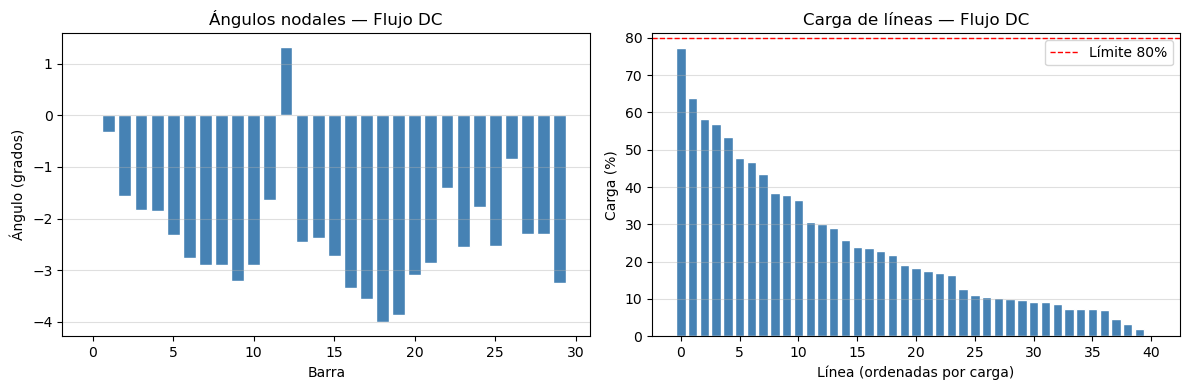


Línea más cargada: 9 (5→7) — 77.3%

¿Cuántas líneas superan el 50% de carga?

Total de líneas con carga > 50%: 5

¿Cual es la barra con mayor ángulo absoluto?
Barra 18: -4.0089 grados

¿Qué diferencias observas respecto a la red IEEE 14-bus?
Comparando con la red IEEE 14-bus, la red IEEE 30-bus esta más cargada con líneas que superan el 50% de carga, lo que indica un sistema más estresado. Además, la topología es más compleja, con más barras y líneas
por otro lado los ángulos nodales de la red de 14 barras son mayores que la de 30 barras a pesar de estar menos cargada en porcentaje, ello que indica que la red de 14 barras es más sensible a los cambios de carga y generación, por ende mas inestable
se nota ademas que en la red de 14 barras, todas las barras tienen ángulos negativos respecto a la barra slack, mientras que en la red de 30 barras existe una barra que posee un ángulo positivo, lo que sugiere que existe fuerte generación en esa barra 12.


In [43]:
# ============================================================
# EJERCICIO AUTÓNOMO — Red IEEE 30-bus
# Completa los apartados marcados con TODO
# ============================================================

# TODO 1: Carga la red IEEE 30-bus
# Pista: usa pn.case30()
net30 = pn.case30()

# TODO 2: Imprime el resumen de la red (número de barras, líneas, generadores, cargas)
print(net30)

# TODO 3: Visualiza el diagrama unifilar
plot.simple_plot(net30, plot_gens=True)

# TODO 4: Ejecuta el flujo de carga DC
pp.rundcpp(net30)   # DC Power Flow

# TODO 5: Imprime los ángulos nodales ordenados de mayor a menor (en valor absoluto)
angulos = net30.res_bus['va_degree'].abs().sort_values(ascending=False)
print("\nÁngulos nodales (ordenados por valor absoluto):")
for barra, valor in angulos.items():
    print(f"Barra {barra:2d}: {valor:8.4f} grados")

# TODO 6: Identifica las 3 líneas más cargadas e imprime su información
top3_idx = net30.res_line['loading_percent'].sort_values(ascending=False).head(3).index
top3 = net30.res_line.loc[top3_idx, ['p_from_mw', 'loading_percent']]
print("\nTop 3 líneas más cargadas:\n", top3)

# TODO 7: Representa gráficamente la carga de todas las líneas (igual que en el Bloque C)
# --- Visualización: ángulos nodales ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Ángulos de tensión
axes[0].bar(net30.res_bus.index, net30.res_bus['va_degree'], color='steelblue', edgecolor='white')
axes[0].set_xlabel('Barra')
axes[0].set_ylabel('Ángulo (grados)')
axes[0].set_title('Ángulos nodales — Flujo DC')
axes[0].grid(True, axis='y', alpha=0.4)

# Carga de líneas
loading = net30.res_line['loading_percent'].sort_values(ascending=False)
colors = ['tomato' if v > 80 else 'steelblue' for v in loading]
axes[1].bar(range(len(loading)), loading.values, color=colors, edgecolor='white')
axes[1].axhline(80, color='red', linestyle='--', linewidth=1, label='Límite 80%')
axes[1].set_xlabel('Línea (ordenadas por carga)')
axes[1].set_ylabel('Carga (%)')
axes[1].set_title('Carga de líneas — Flujo DC')
axes[1].legend()
axes[1].grid(True, axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

# Línea más cargada
idx_max30 = net30.res_line['loading_percent'].idxmax()
print(f"\nLínea más cargada: {idx_max30} "
      f"({net30.line.loc[idx_max30, 'from_bus']}→{net30.line.loc[idx_max30, 'to_bus']}) "
      f"— {net30.res_line.loc[idx_max30, 'loading_percent']:.1f}%")

print(f"\n¿Cuántas líneas superan el 50% de carga?")
num_superan_50 = (net30.res_line['loading_percent'] > 50).sum()
print(f"\nTotal de líneas con carga > 50%: {num_superan_50}")

print(f"\n¿Cual es la barra con mayor ángulo absoluto?")
barra_max_angulo = net30.res_bus['va_degree'].abs().idxmax()
print(f"Barra {barra_max_angulo}: {net30.res_bus.loc[barra_max_angulo, 'va_degree']:.4f} grados")

print(f"\n¿Qué diferencias observas respecto a la red IEEE 14-bus?")
print(f"Comparando con la red IEEE 14-bus, la red IEEE 30-bus esta más cargada con líneas que superan el 50% de carga, lo que indica un sistema más estresado. Además, la topología es más compleja, con más barras y líneas")
print(f"por otro lado los ángulos nodales de la red de 14 barras son mayores que la de 30 barras a pesar de estar menos cargada en porcentaje, ello que indica que la red de 14 barras es más sensible a los cambios de carga y generación, por ende mas inestable")
print(f"se nota ademas que en la red de 14 barras, todas las barras tienen ángulos negativos respecto a la barra slack, mientras que en la red de 30 barras existe una barra que posee un ángulo positivo, lo que sugiere que existe fuerte generación en esa barra 12.")
